In [1]:
import numpy as np
import pandas as pd
import os
import random
import time
from sklearn.decomposition import PCA, FastICA, FactorAnalysis
from sklearn.random_projection import GaussianRandomProjection
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# Set constants.
INPUT_FOLDER_PATH = '../dataProcessedINTERFACE'
FILE_PATTERN = os.path.join(INPUT_FOLDER_PATH, 'temporalInformation*.json')
RANDOM_STATE = 1618
METHODS = {
    "PCA": PCA(n_components=2, random_state=RANDOM_STATE),
    "ICA": FastICA(n_components=2, random_state=RANDOM_STATE),
    "RP": GaussianRandomProjection(n_components=2, random_state=RANDOM_STATE),
    "t-SNE": TSNE(n_components=2, random_state=RANDOM_STATE),
    # 10 neighbors works well in most scenarios - https://umap-learn.readthedocs.io/en/latest/how_umap_works.html
    "UMAP": umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=10),
    "FA": FactorAnalysis(n_components=2, random_state=RANDOM_STATE)
}

# Set random variables.
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = f'{RANDOM_STATE}'
random.seed(RANDOM_STATE)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
# ------ Helper Functions ------
# make knn helper function
def knn_preservation_score(X_high, X_low, k=5):
    knn_high = NearestNeighbors(n_neighbors=k).fit(X_high)
    knn_low = NearestNeighbors(n_neighbors=k).fit(X_low)
    neighbors_high = knn_high.kneighbors(return_distance=False)
    neighbors_low = knn_low.kneighbors(return_distance=False)
    score = np.mean([
        len(set(high).intersection(set(low))) / k
        for high, low in zip(neighbors_high, neighbors_low)
    ])
    return score

# formula adapted from https://link.springer.com/chapter/10.1007/3-540-44668-0_68#preview and https://www.sciencedirect.com/science/article/pii/S0893608006000724 (M2(k) formula)
def continuity(X_high, X_low, k=5):
    # number of samples
    n = X_high.shape[0]
    # build rank matrices
    nn_high = NearestNeighbors(n_neighbors=n-1).fit(X_high)
    rank_matrix_high = nn_high.kneighbors(return_distance=False)
    nn_low = NearestNeighbors(n_neighbors=k + 1).fit(X_low)
    neighbors_low = nn_low.kneighbors(return_distance=False)[:,1:]
    
    penalty = 0
    for i in range(n):
        ranks = {point: rank for rank, point in enumerate(rank_matrix_high[i], start=1)}
        
        for j in neighbors_low[i]:
            if j not in rank_matrix_high[i][:k]:  # j is not a high-d neighbor
                penalty += ranks.get(j, n) - k

    denom = n * k * (2 * n - 3 * k - 1)
    continuity_score = 1 - (2 / denom) * penalty
    return continuity_score

In [4]:
files = sorted(
    glob.glob(FILE_PATTERN),
    key=lambda x: int(
        os.path.basename(x)
        .replace('temporalInformation', '')
        .replace('.json', '')
        .replace('P', '')
    )
)

temp_dfs = []
for file_path in files:
    temp_dfs.append(pd.read_json(file_path))

big_df = pd.concat(temp_dfs)

In [5]:
embeddings_columns = [column for column in big_df.columns if 'Embeddings' in column]
embeddings_dict = {}
for embeddings_column in embeddings_columns:
    if 'Nurse' in embeddings_column:
        print(f"{embeddings_column}: {len(big_df.dropna(subset=[embeddings_column]))}")
        temp_embeddings = np.array(big_df.dropna(subset=[embeddings_column])[embeddings_column].values.tolist())
        temp_results = []
        for name, model in METHODS.items():
            start = time.time()
            trans_embeddings = model.fit_transform(temp_embeddings)
            end = time.time()
            temp_results.append({
                "Method": name,
                # using k = 5 as it is common (https://www.nature.com/articles/s42003-022-03628-x)
                "Trustworthiness": trustworthiness(temp_embeddings, trans_embeddings, n_neighbors=5),
                "KNN Preservation": knn_preservation_score(temp_embeddings, trans_embeddings, k=5),
                "Continuity": continuity(temp_embeddings, trans_embeddings, k=5),
                "Time": end-start
            })
        embeddings_dict[embeddings_column] = temp_results

Nurse Note - Embeddings: 12373


/Users/isabel/anaconda3/envs/realData/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_15890/2974990767.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Method", y=title, palette="Set2")
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_15890/2974990767.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Method", y=title, palette="Set2")
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_15890/2974990767.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Method", y=title, palette="Set2"

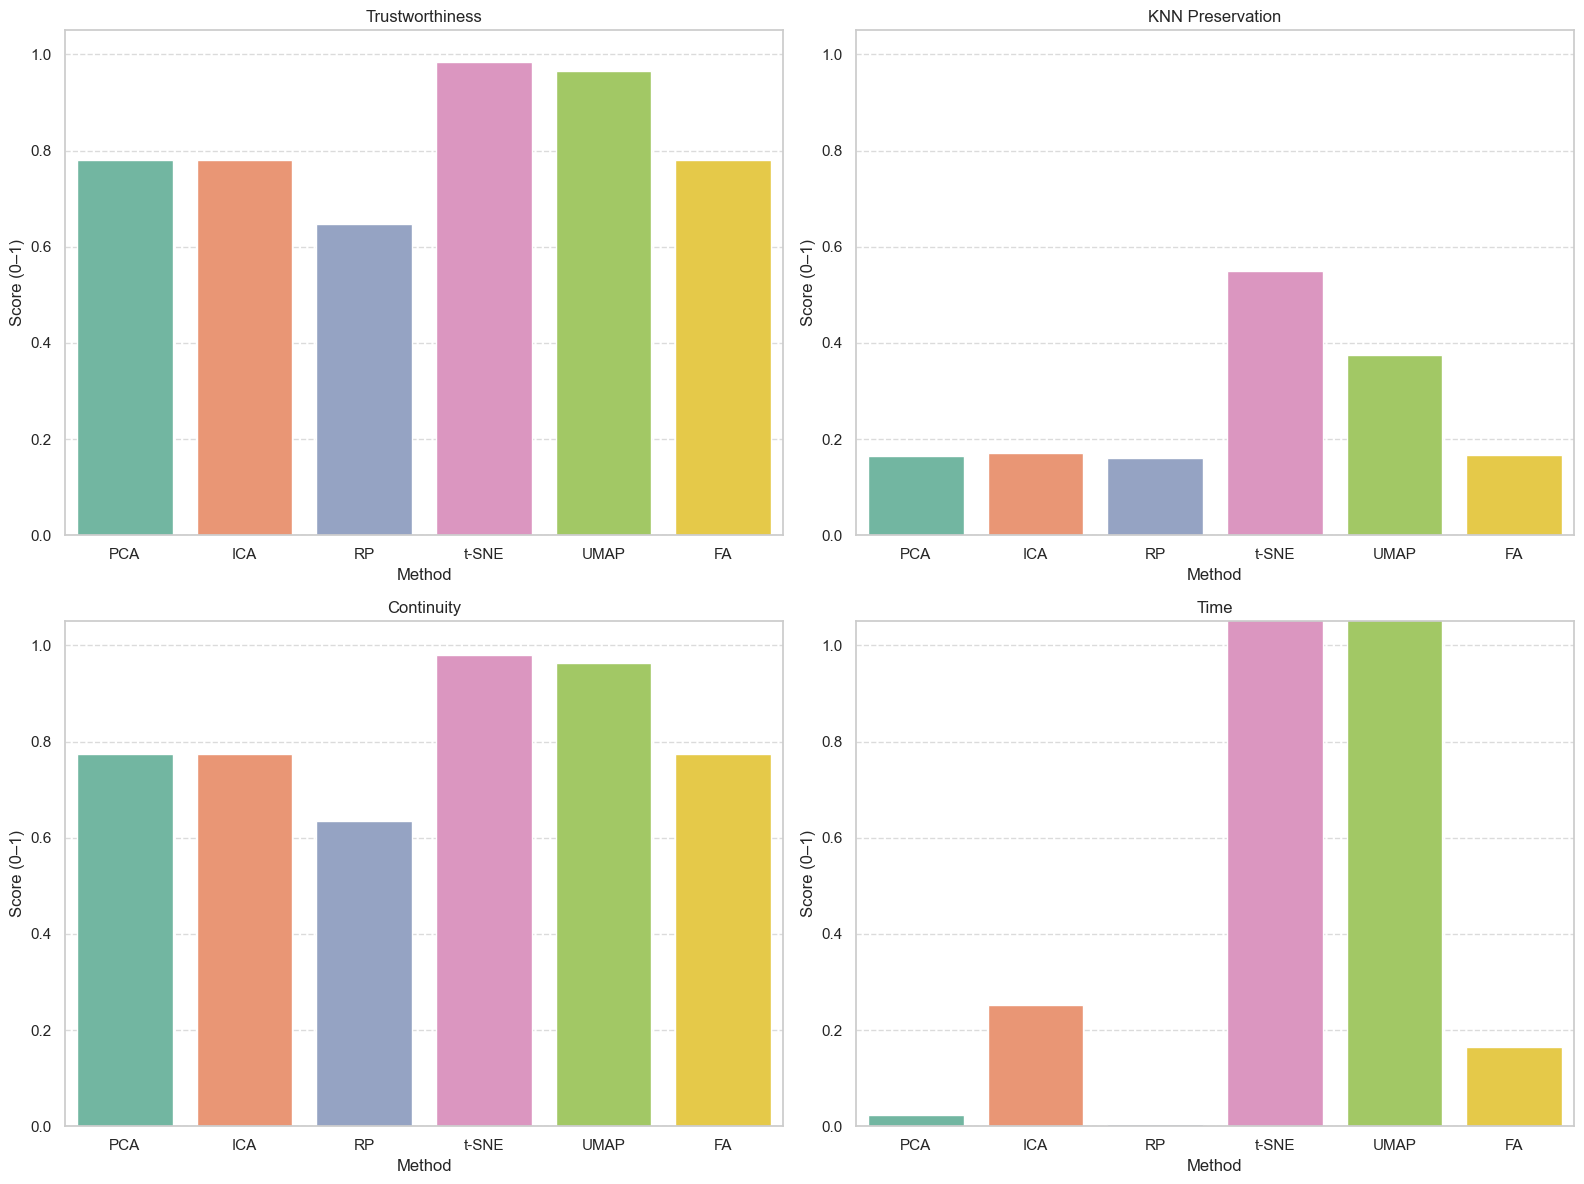

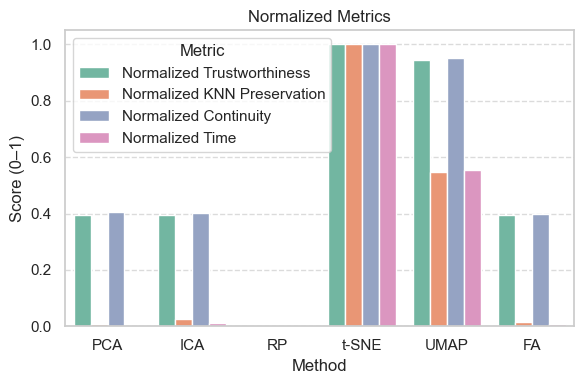

In [6]:
for key, value in embeddings_dict.items():
    df_results = pd.DataFrame(value)
    df_normalized = pd.DataFrame()
    df_normalized['Method'] = df_results['Method']
    df_normalized['Normalized Trustworthiness'] = (df_results['Trustworthiness'] - df_results['Trustworthiness'].min()) / (df_results['Trustworthiness'].max() - df_results['Trustworthiness'].min())   
    df_normalized['Normalized KNN Preservation'] = (df_results['KNN Preservation'] - df_results['KNN Preservation'].min()) / (df_results['KNN Preservation'].max() - df_results['KNN Preservation'].min())   
    df_normalized['Normalized Continuity'] = (df_results['Continuity'] - df_results['Continuity'].min()) / (df_results['Continuity'].max() - df_results['Continuity'].min())   
    df_normalized['Normalized Time'] = (df_results['Time'] - df_results['Time'].min()) / (df_results['Time'].max() - df_results['Time'].min())   

    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(16, 12))

    titles = ['Trustworthiness', 'KNN Preservation', 'Continuity', 'Time']

    for i, title in enumerate(titles, start=1):
        plt.subplot(2, 2, i)
        sns.barplot(data=df_results, x="Method", y=title, palette="Set2")
        plt.title(title)
        plt.ylim(0, 1.05)
        plt.ylabel("Score (0–1)")
        plt.grid(axis='y', linestyle='--', alpha=0.7)


    plt.tight_layout()
    plt.show()

    # save normalized metrics figure
    plt.figure(figsize=(6, 4))

    df_melted = df_normalized.melt(id_vars="Method", var_name="Metric", value_name="Normalized Score")
    sns.barplot(data=df_melted, x="Method", y="Normalized Score", hue="Metric", palette="Set2")
    plt.title("Normalized Metrics")
    plt.ylim(0, 1.05)
    plt.ylabel("Score (0–1)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # # save plot
    # if os.path.exists(f'../figures/dimRed/'):
    #     plt.savefig("../figures/dimRed/normalizedMetricsAllModels.png", bbox_inches='tight', dpi=300, format='png')
    # else:
    #     os.makedirs(f'../figures/dimRed/', exist_ok=False)
    #     plt.savefig("../figures/dimRed/normalizedMetricsAllModels.png", bbox_inches='tight', dpi=300, format='png')

    plt.show()